In [750]:
min_voltage, max_voltage, voltage_iter = -140, 142, 2

In [751]:
voltage_range_subset=np.arange(-140,142,2)

In [752]:
import numpy as np

# Define a function to parse an S2P file assuming RI format
def parse_s2p(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Skip header lines and parse data lines
    data_lines = [line for line in lines if not line.startswith('!') and not line.startswith('#')]

    # Initialize lists to store frequencies and S-parameters
    frequencies = []
    s_params = []

    # Process each line of data
    for line in data_lines:
        parts = line.split()
        frequency = float(parts[0])
        # The rest of the parts are S-parameters in RI format
        s_param = np.array([float(part) for part in parts[1:]])
        frequencies.append(frequency)
        s_params.append(s_param)

    return np.array(frequencies), np.array(s_params)

# Example usage
# frequencies, s_parameters = parse_s2p('/mnt/data/example_data.s2p')

### import data, make basic calculations of admittance, Q and Capacitance and dynamically store those as new columns as we iterate through the voltages

In [753]:
# Assuming 'frequencies' is your array of frequencies and 'all_data' your DataFrame
selected_frequencies = frequencies  # All frequencies of interest
voltages = voltage_range_subset  # Voltage values


In [754]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm


plt.rcParams["figure.figsize"]=[6,7] #8,8
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }


legend_font = {'family': font['family'], 'size': font['size']}  # Define font properties for legend


def fitting_function(V, Cmax, V_half, Cf):
    return (Cmax - Cf) / (2 * np.cosh(2/3 * np.arcsinh(2 * V / V_half))-1) + Cf


In [755]:
base_directory = "/Users/aaronburger/Documents/PhaseShifterRelated/BST70A13GSO-D"


In [756]:
def func_get_Sparams_Y_params_Q_C(s_parameters,angular_frequencies):
        # Extract the S-parameters
    S11 = s_parameters[:, 0] + 1j * s_parameters[:, 1]  # S11
    S21 = s_parameters[:, 2] + 1j * s_parameters[:, 3]  # S21
    S12 = s_parameters[:, 4] + 1j * s_parameters[:, 5]  # S12, should be equal to S21 for reciprocal networks
    S22 = s_parameters[:, 6] + 1j * s_parameters[:, 7]  # S22

    # Characteristic admittance (inverse of Z0)
    Y0 = 1 / Z0

    # Calculate the determinant of the S-parameter matrix
    Delta = (1 + S11) * (1 + S22) - S12 * S21

    # Calculate Y-parameters
    Y11 = Y0 * ((1 - S11) * (1 + S22) + S12 * S21) / Delta
    Y12 = Y0 * (-2 * S12) / Delta
    Y21 = Y0 * (-2 * S21) / Delta
    Y22 = Y0 * ((1 + S11) * (1 - S22) + S12 * S21) / Delta

    # Calculate Q from the imaginary and real parts of Y21
    Q = np.abs(np.imag(Y21) / np.real(Y21))


    # Calculate capacitance from the imaginary part of Y12 (or Y21)
    capacitance = abs(np.imag(Y12)) / angular_frequencies
    
    Nonrecip=np.imag(S12-S21)#/abs(S11)
    
    return Q, capacitance, Nonrecip, S12, S21

In [757]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Define the parameters for the experiment
min_voltage, max_voltage, voltage_iter = -140, 140, 2
finger_counts = [6, 10, 12, 14, 16]  # Example finger counts



# Initialize a DataFrame to hold all the data
all_results = []

# Iterate over each finger count
for finger_count in finger_counts:
    data_dict = {}
    # Adjust the file path depending on the finger count and voltage
    for voltage in range(min_voltage, max_voltage + 1, voltage_iter):
        if voltage < 0:
            file_name = f"{base_directory}/0_Degrees/BST70A13GSO-0D{finger_count}F140V2S-D/S2P/BST70A13GSO_0D{finger_count}F140V2S_D_N{abs(voltage)}V_dev.s2p"
            #file_name = f"{base_directory}XXXXA13XXX-{finger_count}F140V2S-D/S2P/XXXXA13XXX_{finger_count}F140V2S_D_N{abs(voltage)}V_dev.s2p"
        else:
            file_name = f"{base_directory}/0_Degrees/BST70A13GSO-0D{finger_count}F140V2S-D/S2P/BST70A13GSO_0D{finger_count}F140V2S_D_{voltage}V_dev.s2p"
            #file_name = f"{base_directory}XXXXA13XXX-{finger_count}F140V2S-D/S2P/XXXXA13XXX_{finger_count}F140V2S_D_{voltage}V_dev.s2p"
        
        # Parse the S2P file
        frequencies, s_parameters = parse_s2p(file_name)
        angular_frequencies = 2 * np.pi * frequencies
        
        Q, capacitance, Nonrecip, S12, S21= func_get_Sparams_Y_params_Q_C(s_parameters,angular_frequencies)
        
        # Store data in dictionary
        data_dict[f'Q_{voltage:+d}V'] = Q
        data_dict[f'C_{voltage:+d}V'] = capacitance
        data_dict[f'Frequency'] = frequencies  # Assume same frequencies for all measurements
    
    # Create a DataFrame for the current finger count and add to results
    df = pd.DataFrame(data_dict)
    df['Finger Count'] = finger_count
    df['Angle'] = 0
    all_results.append(df)

# Concatenate all results into a single DataFrame
all_data = pd.concat(all_results, ignore_index=True)


In [758]:
initial_guess

[2.920232627964773e-13, -22, 1e-14]

In [759]:
def fitting_function(V, Cmax, V_half, Cf):
    return (Cmax - Cf) / (2 * np.cosh(2/3 * np.arcsinh(2 * V / V_half))-1) + Cf


def func_curve_fitting(Cmax,V_half,fitting_function,voltages, capacitance_data):
# Perform curve fitting
    initial_guess = [Cmax, V_half, 1e-14]  # Adjust as needed
    bounds = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    #bounds = ([1e-13,-100,0], [5e-12, 100, 5e-14])
    popt, _ = curve_fit(fitting_function, voltages, capacitance_data, p0=initial_guess, bounds=bounds)
    return(popt)

In [760]:

# Initialize a datadict to store fitting parameters (1/3)
data_dicts=[]

# Assuming 'frequencies' is your array of frequencies and 'all_data' your DataFrame
selected_frequencies = frequencies  # All frequencies of interest
voltages = voltage_range_subset  # Voltage values


# Initialize arrays to store the fitting parameters
Cmax_values = []
V_half_values = []
Cf_values = []


subset = all_data[all_data['Finger Count'] == finger_count]
subset = subset.reset_index(drop=True)  #without this, the indexing isn't right for 
##the subset data frame, and when you try later to slice it it won't work...


for i, freq in enumerate(selected_frequencies):
#for i, freq in enumerate(frequencies):
    frequency_index = np.abs(frequencies - freq).argmin()
    capacitance_data = [subset.at[frequency_index, f'C_{v:+d}V'] for v in voltages] 
    
    #slices the dataframe along 
    ## just one frequency to get Capacitance values as a
    ###function of voltage for that frequency only, puts it into a new list capacitance_data

    # Find Cmax and the corresponding V_half directly from the data
    Cmax = np.max(capacitance_data)
    Cmin = np.min(capacitance_data) # or 0
    C_half = Cmin + (Cmax - Cmin) / 2
    V_half = voltages[np.argmin(np.abs(capacitance_data - C_half))]

    # Perform curve fitting
    popt = func_curve_fitting(Cmax,V_half,fitting_function,voltages, capacitance_data)
    
    # Store the fitting parameters
    Cmax_values.append(popt[0])  #see fitting function, this is storing optim. value of cmax
    V_half_values.append(popt[1]) #see fitting function, this is storing optim. value of vhalf
    Cf_values.append(popt[2]) #see fitting function, this is storing optim. value of fringing cap
    
    ##### this is the new part, adding the fitting parameters to the data 
    ### dictionaries that wind up in the dataframe
    ## After fitting, store the parameters in the datadicts (2/3)   
    data_dicts.append({
        'Frequency': freq,
        'Cmax_fitted': popt[0],
        'V_half': popt[1],
        'Cf': popt[2],
        #'Cmax_measd': ,
        'Cmin':Cmin
    })
    
    # Generate data for the fitted curve
    #V_fit = np.linspace(min(voltages), max(voltages), 1000)
    #C_fit = fitting_function(V_fit, *popt)

fitting_params_df_0_degrees_16_fingers = pd.DataFrame(data_dicts)
fitting_params_df_0_degrees_16_fingers['C_Max_measd']=subset[f'C_+0V'] #drags the measured values of the V=0 capacit along 

# Calculate tunability as the ratio of Cmax_measd to Cmin for each row (frequency)
fitting_params_df_0_degrees_16_fingers['Tunability'] = fitting_params_df_0_degrees_16_fingers['C_Max_measd'] / fitting_params_df_0_degrees_16_fingers['Cmin']

# Add 'Angle' and 'Number of Fingers' columns to df_0_degrees
fitting_params_df_0_degrees_16_fingers['Angle'] = 0  # Assuming all measurements in this DataFrame are at 0 degrees
fitting_params_df_0_degrees_16_fingers['Number of Fingers'] = 16  # Assuming all measurements in this DataFrame are for 6

    

In [761]:
fitting_params_df_0_degrees_16_fingers

,Frequency,Cmax_fitted,V_half,Cf,Cmin,C_Max_measd,Tunability,Angle,Number of Fingers
0,1.000000e+07,4.135968e-13,-35.036158,5.138386e-14,7.450726e-14,4.471824e-13,6.001863,0,16
1,1.999623e+07,4.249345e-13,-35.214015,4.960292e-14,1.115258e-13,4.354489e-13,3.904467,0,16
2,2.999245e+07,4.256775e-13,34.956547,5.107895e-14,1.123516e-13,4.343383e-13,3.865883,0,16
3,3.998868e+07,4.265253e-13,34.875688,5.092632e-14,1.147919e-13,4.319430e-13,3.762835,0,16
4,4.998491e+07,4.266027e-13,34.715469,5.136938e-14,1.162451e-13,4.325692e-13,3.721181,0,16
...,...,...,...,...,...,...,...,...,...
2646,2.646002e+10,2.275953e-12,12.222732,-7.936754e-14,1.537135e-13,2.192687e-12,14.264762,0,16
2647,2.647001e+10,2.293276e-12,12.137879,-7.981674e-14,1.539545e-13,2.207594e-12,14.339265,0,16
2648,2.648001e+10,2.300999e-12,12.087195,-7.968785e-14,1.541272e-13,2.213911e-12,14.364180,0,16
2649,2.649000e+10,2.306907e-12,12.058648,-7.989739e-14,1.542215e-13,2.219773e-12,14.393402,0,16


in the above blocks of code, take the all_data data frame created previously as an input and find a subset of all_data for a particular finger count, inside a loop, or something similar. 

Using that subset, I fit the capacitance data at each frequency using the fitting functions. Right now I'm manually creating a new data frame called fitting_params_df_0_degrees_{16}_fingers and storing the optimized fitting parameters: Halfway voltage, fringe capacitance, and minimum capacitance, fitted max capacitance, along with the measured Max capacitance, calculated tunability. idc angle, and finger number variables are also stored at this step in the new dataframe. This new data frame needs to get passed to a larger data frame that includes each of the different finger numbers in the new loop.

In [762]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


finger_counts = [6, 10, 12, 14, 16]  # Example finger counts

# Initialize a list to hold all the DataFrames for different finger counts
all_finger_dfs = []

# Iterate over each finger count
for finger_count in finger_counts:
    # Initialize a list for this finger count's fitting parameters
    data_dicts = []

    # Get the subset DataFrame for the current finger count
    subset = all_data[all_data['Finger Count'] == finger_count]
    subset = subset.reset_index(drop=True)

    # Iterate over frequencies and perform fitting
    for freq in selected_frequencies:
        frequency_index = np.abs(subset['Frequency'] - freq).argmin()
        capacitance_data = [subset.at[frequency_index, f'C_{v:+d}V'] for v in voltages]

        Cmax = np.max(capacitance_data)
        Cmin = np.min(capacitance_data)
        C_half = Cmin + (Cmax - Cmin) / 2
        V_half = voltages[np.argmin(np.abs(capacitance_data - C_half))]

        # Perform curve fitting
        popt = func_curve_fitting(Cmax, V_half, fitting_function, voltages, capacitance_data)

        # Store the fitting parameters
        data_dicts.append({
            'Finger Count': finger_count,
            'Frequency': freq,
            'Cmax_fitted': popt[0],
            'V_half': np.abs(popt[1]),
            'Cf': popt[2],
            'Cmin': Cmin,
            'C_Max_measd': subset.at[frequency_index, 'C_+0V']
        })

    # Create a DataFrame for this finger count and append to the list
    df_finger = pd.DataFrame(data_dicts)
    df_finger['Tunability'] = df_finger['C_Max_measd'] / df_finger['Cmin']
    df_finger['Angle'] = 0  # Assuming measurements at 0 degrees
    df_finger['Number of Fingers'] = finger_count  # Assuming measurements at 0 degrees
    
    all_finger_dfs.append(df_finger)

# Concatenate all results into a single DataFrame
all_fingers_data = pd.concat(all_finger_dfs, ignore_index=True)


In [763]:
all_fingers_data

,Finger Count,Frequency,Cmax_fitted,V_half,Cf,Cmin,C_Max_measd,Tunability,Angle,Number of Fingers
0,6,1.000000e+07,2.835225e-13,32.122070,2.974451e-14,3.882569e-14,3.108411e-13,8.006067,0,6
1,6,1.999623e+07,2.868619e-13,30.484207,3.718956e-14,6.930141e-14,2.798202e-13,4.037728,0,6
2,6,2.999245e+07,2.899161e-13,29.065524,3.891943e-14,7.644216e-14,2.950745e-13,3.860102,0,6
3,6,3.998868e+07,2.907588e-13,28.677171,3.995254e-14,7.746014e-14,2.930778e-13,3.783595,0,6
4,6,4.998491e+07,2.900049e-13,28.900859,3.954215e-14,7.791003e-14,2.926118e-13,3.755766,0,6
...,...,...,...,...,...,...,...,...,...,...
13250,16,2.646002e+10,2.275953e-12,12.222732,-7.936754e-14,1.537135e-13,2.192687e-12,14.264762,0,16
13251,16,2.647001e+10,2.293276e-12,12.137879,-7.981674e-14,1.539545e-13,2.207594e-12,14.339265,0,16
13252,16,2.648001e+10,2.300999e-12,12.087195,-7.968785e-14,1.541272e-13,2.213911e-12,14.364180,0,16
13253,16,2.649000e+10,2.306907e-12,12.058648,-7.989739e-14,1.542215e-13,2.219773e-12,14.393402,0,16


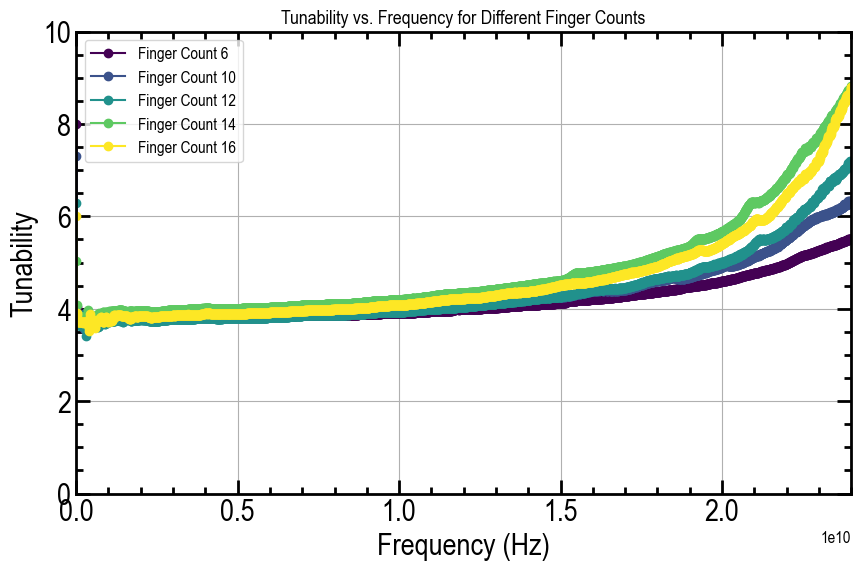

In [764]:
# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))


plt.rcParams["figure.figsize"]=[6.5,7]
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

# Define a colormap or use distinct markers if preferred
colors = plt.cm.viridis(np.linspace(0, 1, len(finger_counts)))

for count, color in zip(finger_counts, colors):
    # Filter the data for the current finger count
    subset = all_fingers_data[all_fingers_data['Finger Count'] == count]

    # Plotting
    ax.plot(subset['Frequency'], subset['Tunability'], label=f'Finger Count {count}', color=color, marker='o')

# Adding labels and title
ax.set_xlabel('Frequency (Hz)', fontdict=font)
ax.set_ylabel('Tunability',fontdict=font)
ax.set_title('Tunability vs. Frequency for Different Finger Counts', fontsize=14)
plt.xlim(0,2.4e10)
plt.ylim(0,10)

# Adding a legend to differentiate the lines
ax.legend()

plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.legend()

plt.grid(True)
###########################################################################################

# Show the plot
plt.show()


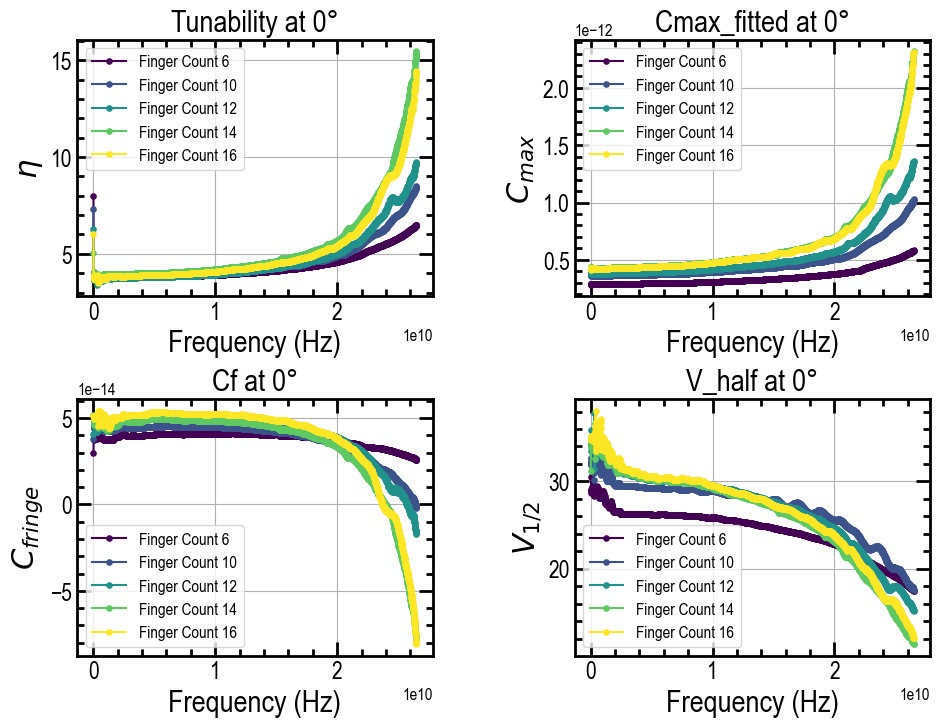

In [772]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


#plt.rcParams["figure.figsize"]=[6.5,7]
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

# Fetch angle, assuming it's consistent for now
# Check if 'Angle' column exists and handle it if not
if 'Angle' in all_fingers_data.columns:
    angle = all_fingers_data['Angle'].iloc[0]
else:
    angle = 0  # Default value if no angle data is present

# Create a figure with subplots arranged in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(11, 8))  # Adjust size to fit your PPT slide
fig.subplots_adjust(hspace=0.4, wspace=0.4)  # Adjust spacing to prevent label overlap

# Define a colormap or use distinct markers
colors = plt.cm.viridis(np.linspace(0, 1, len(finger_counts)))

# Define metrics for easier iteration
metrics = [('Tunability', '$\eta$'),
           ('Cmax_fitted', '$C_{max}$'),
           ('Cf', '$C_{fringe}$'),
           ('V_half', '$V_{1/2}$')]

# Loop through the metrics and create a plot for each one
for ax, (metric_key, title) in zip(axs.flat, metrics):
    for count, color in zip(finger_counts, colors):
        subset = all_fingers_data[all_fingers_data['Finger Count'] == count]
        ax.plot(subset['Frequency'], subset[metric_key], label=f'Finger Count {count}', color=color, marker='.',markersize=7.5)
    ax.set_title(f'{metric_key} at {angle}°',fontdict=font)  # Include angle in the title
    ax.set_xlabel('Frequency (Hz)',fontdict=font)
    ax.set_ylabel(title,fontdict=font)
    ax.legend()
    ax.minorticks_on()
    ax.grid(True)

    # Customizing x-axis tick parameters
    ax.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on',labelsize=17)
    ax.xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on',labelsize=17)

    # Customizing y-axis tick parameters
    ax.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on',labelsize=17)
    ax.yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off',labelsize=17)


    
# Show the plot
plt.show()


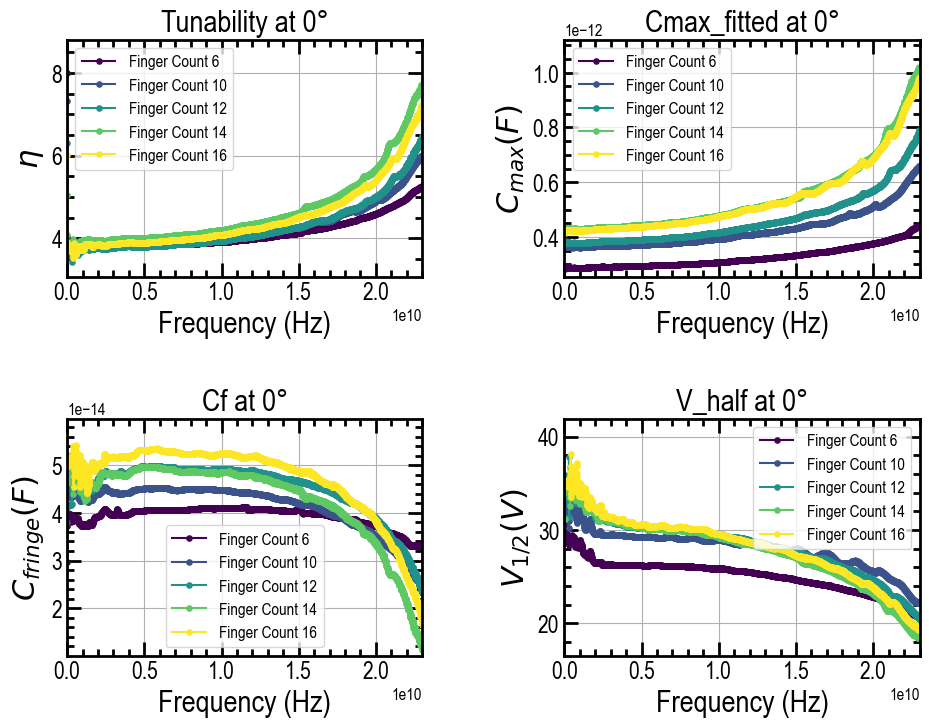

In [770]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fmaxplot=23e9

plt.rcParams["figure.autolayout"] = False
plt.rcParams['axes.linewidth'] = 2
font = {'family': 'Arial Narrow', 'color': 'black', 'weight': 'normal', 'size': 22}

# Create a figure with subplots arranged in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

# Define a colormap or use distinct markers
colors = plt.cm.viridis(np.linspace(0, 1, len(finger_counts)))

# Define metrics for easier iteration
metrics = [('Tunability', '$\eta$'),
           ('Cmax_fitted', '$C_{max}(F)$'),
           ('Cf', '$C_{fringe}(F)$'),
           ('V_half', '$V_{1/2}(V)$')]

for ax, (metric_key, title) in zip(axs.flat, metrics):
    ax.ymin, ax.ymax = float('inf'), float('-inf')  # Initialize to extreme values
    for count, color in zip(finger_counts, colors):
        subset = all_fingers_data[(all_fingers_data['Finger Count'] == count) & (all_fingers_data['Frequency'] <= fmaxplot)]
        if not subset.empty:
            ax.plot(subset['Frequency'], subset[metric_key], label=f'Finger Count {count}', color=color, marker='.', markersize=7.5)
            current_min, current_max = subset[metric_key].min(), subset[metric_key].max()
            ax.ymin = min(ax.ymin, current_min)
            ax.ymax = max(ax.ymax, current_max)

    ax.set_title(f'{metric_key} at {angle}°', fontdict=font)
    ax.set_xlabel('Frequency (Hz)', fontdict=font)
    ax.set_ylabel(title, fontdict=font)
    ax.legend()
    ax.minorticks_on()
    ax.grid(True)
    ax.set_xlim(0, fmaxplot)  # Limit x-axis from 0 to 23 GHz
    ax.set_ylim(ax.ymin - 0.1 * abs(ax.ymin), ax.ymax + 0.1 * abs(ax.ymax))  # Adjust y-axis with padding

    # Customize x-axis and y-axis tick parameters specifically for each ax
    ax.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax.xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')
    ax.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax.yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

    # Setting font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.tick_params(axis='both', which='minor', labelsize=17)

plt.show()


### the graphs below are from the original data frame, basic calcs from raw data, plotting measured Cmax(V=0) and Q factors for whatever voltage you want... 

In [669]:
finger_count

16

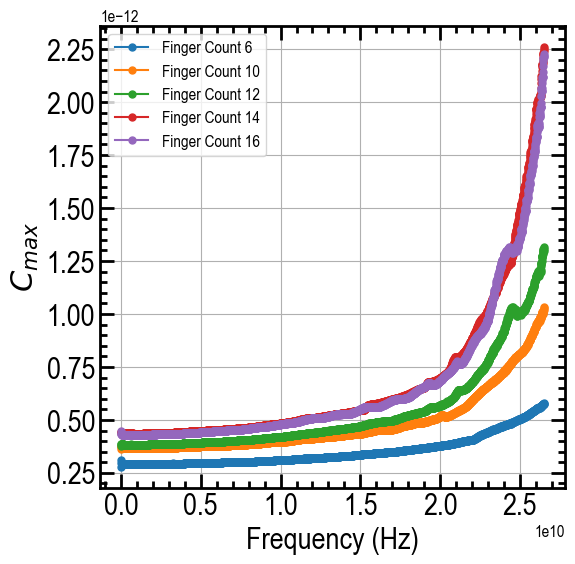

In [689]:

# Plotting Example: Plot Cmax vs Frequency for each finger count
plt.figure(figsize=(6, 6))
for finger_count in finger_counts:
    subset = all_data[all_data['Finger Count'] == finger_count]
    plt.plot(subset['Frequency'], subset['C_+0V'],marker='.',markersize=10, label=f'Finger Count {finger_count}')

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.ylabel('$C_{max}$',fontdict=font)
#plt.title('Tunability',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
plt.legend()

plt.grid(True)
###########################################################################################


plt.show()


In [690]:
all_data[all_data['Finger Count'] == finger_count]

,Q_-140V,C_-140V,Frequency,Q_-138V,C_-138V,Q_-136V,C_-136V,Q_-134V,C_-134V,Q_-132V,...,Q_+134V,C_+134V,Q_+136V,C_+136V,Q_+138V,C_+138V,Q_+140V,C_+140V,Finger Count,Angle
10604,14.175155,1.197566e-13,1.000000e+07,4.432426,1.110219e-13,8.186039,9.959929e-14,4.841642,1.106103e-13,3.797609,...,17.851515,1.310170e-13,4.465390,1.476815e-13,7.964743,9.697845e-14,2.679059,1.224286e-13,16,0
10605,54.313332,1.201922e-13,1.999623e+07,25.757307,1.225009e-13,74.236507,1.186320e-13,25.659257,1.136733e-13,16.292970,...,12.050270,1.190427e-13,30.859407,1.209556e-13,16.982403,1.126166e-13,48.529066,1.213409e-13,16,0
10606,11698.497975,1.161922e-13,2.999245e+07,35.885521,1.123516e-13,51.352945,1.173349e-13,53.803440,1.219049e-13,109.572194,...,97.982164,1.182470e-13,62.789978,1.179962e-13,41.140665,1.170561e-13,44.152989,1.174381e-13,16,0
10607,298.101251,1.160816e-13,3.998868e+07,239.171966,1.176457e-13,73.853848,1.189400e-13,78.389182,1.175124e-13,71.309348,...,76.187060,1.186547e-13,102.383463,1.185561e-13,68.381691,1.182172e-13,133.600154,1.147919e-13,16,0
10608,34240.893407,1.162451e-13,4.998491e+07,94.462001,1.180365e-13,372.867682,1.173837e-13,181.930547,1.193670e-13,88.159716,...,93.893853,1.187604e-13,316.921799,1.179026e-13,250.756329,1.174268e-13,406.720269,1.165463e-13,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13250,52.952458,1.537135e-13,2.646002e+10,53.046739,1.548774e-13,52.745367,1.559046e-13,52.452262,1.569300e-13,51.846467,...,52.201867,1.569721e-13,52.971657,1.558417e-13,53.571324,1.548679e-13,52.990846,1.537679e-13,16,0
13251,46.053341,1.539545e-13,2.647001e+10,46.508578,1.551440e-13,45.918367,1.560972e-13,46.261361,1.571440e-13,45.706207,...,46.658615,1.572220e-13,46.466523,1.560620e-13,47.227960,1.550626e-13,46.539669,1.539756e-13,16,0
13252,41.907912,1.541272e-13,2.648001e+10,42.193547,1.553226e-13,41.634693,1.562627e-13,42.141822,1.573148e-13,41.845773,...,42.496752,1.573919e-13,42.465214,1.562516e-13,42.311641,1.552276e-13,42.062663,1.541963e-13,16,0
13253,41.563021,1.542215e-13,2.649000e+10,42.242742,1.553906e-13,41.442967,1.563529e-13,42.229123,1.574245e-13,41.847702,...,42.553661,1.574779e-13,42.179339,1.563299e-13,42.080391,1.553070e-13,41.867520,1.542608e-13,16,0


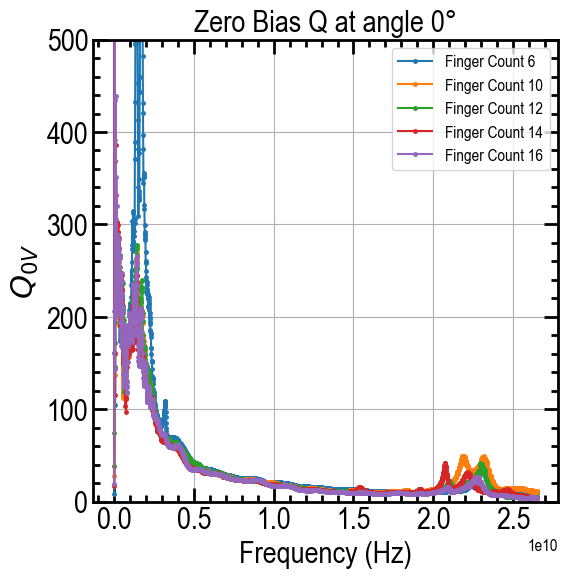

In [694]:
# Plotting Example: Plot Cmax vs Frequency for each finger count
plt.figure(figsize=(6, 6))
for finger_count in finger_counts:
    subset = all_data[all_data['Finger Count'] == finger_count]
    plt.plot(subset['Frequency'], subset['Q_+0V'],marker='.',markersize=5, label=f'Finger Count {finger_count}')

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.ylabel('$Q_{0V}$',fontdict=font)
plt.title(f'Zero Bias Q at IDC angle {angle}°',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
plt.legend()
plt.ylim(0,5e2)

plt.grid(True)
###########################################################################################


plt.show()


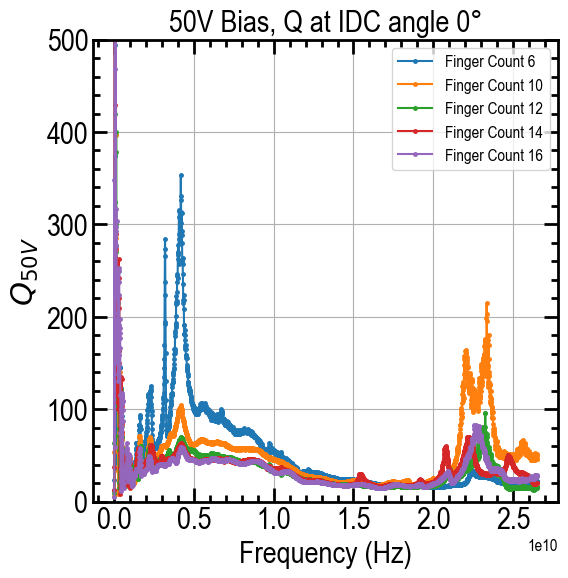

In [695]:
# Plotting Example: Plot Cmax vs Frequency for each finger count
plt.figure(figsize=(6, 6))
for finger_count in finger_counts:
    subset = all_data[all_data['Finger Count'] == finger_count]
    plt.plot(subset['Frequency'], subset['Q_+50V'],marker='.',markersize=5, label=f'Finger Count {finger_count}')

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.ylabel('$Q_{50V}$',fontdict=font)
plt.title(f'50V Bias, Q at IDC angle {angle}°',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
plt.legend()
plt.ylim(0,5e2)

plt.grid(True)
###########################################################################################


plt.show()


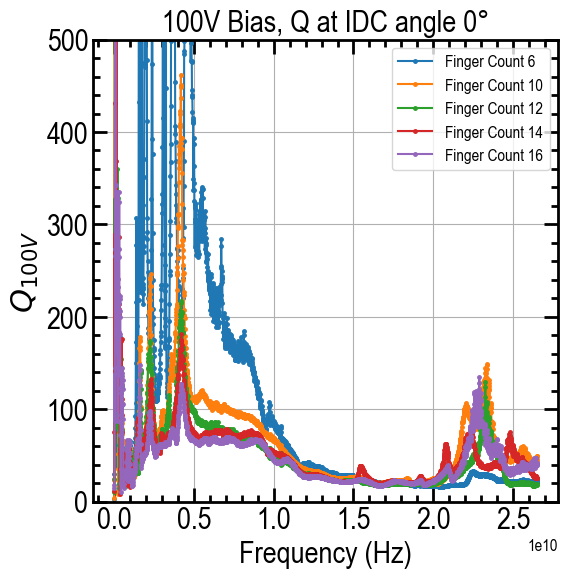

In [696]:
# Plotting Example: Plot Cmax vs Frequency for each finger count
plt.figure(figsize=(6, 6))
for finger_count in finger_counts:
    subset = all_data[all_data['Finger Count'] == finger_count]
    plt.plot(subset['Frequency'], subset['Q_+100V'],marker='.',markersize=5, label=f'Finger Count {finger_count}')

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.ylabel('$Q_{100V}$',fontdict=font)
plt.title(f'100V Bias, Q at IDC angle {angle}°',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
plt.legend()
plt.ylim(0,5e2)

plt.grid(True)
###########################################################################################


plt.show()


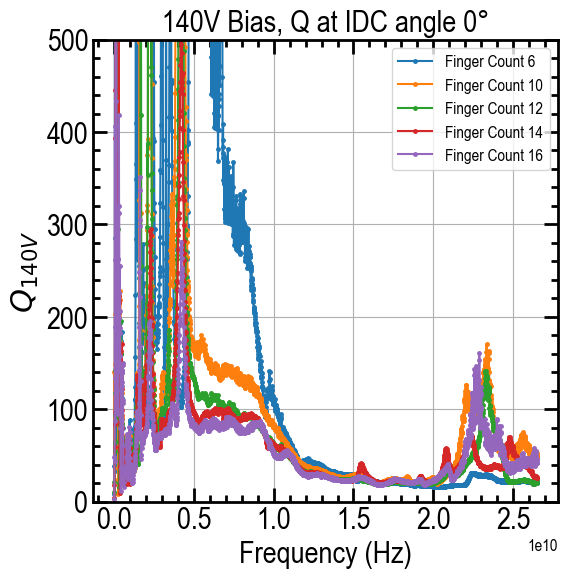

In [702]:
# Plotting Example: Plot Cmax vs Frequency for each finger count
plt.figure(figsize=(6, 6))
for finger_count in finger_counts:
    subset = all_data[all_data['Finger Count'] == finger_count]
    plt.plot(subset['Frequency'], subset['Q_+140V'],marker='.',markersize=5, label=f'Finger Count {finger_count}')

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.ylabel('$Q_{140V}$',fontdict=font)
plt.title(f'140V Bias, Q at IDC angle {angle}°',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
plt.legend()
plt.ylim(0,5e2)

plt.grid(True)
###########################################################################################


plt.show()


In [773]:
all_data

,Q_-140V,C_-140V,Frequency,Q_-138V,C_-138V,Q_-136V,C_-136V,Q_-134V,C_-134V,Q_-132V,...,Q_+134V,C_+134V,Q_+136V,C_+136V,Q_+138V,C_+138V,Q_+140V,C_+140V,Finger Count,Angle
0,25.835126,6.048889e-14,1.000000e+07,3.774128,9.750332e-14,6.272795,6.146937e-14,2.375722,6.007876e-14,3.454091,...,3.515831,5.178623e-14,6.475108,9.891529e-14,4.949982,6.900559e-14,8.017073,4.814417e-14,6,0
1,12.014765,8.047068e-14,1.999623e+07,17.960714,7.891980e-14,39.008849,7.988850e-14,9.645572,7.761794e-14,65.145414,...,22.525407,8.319005e-14,21.504897,7.349054e-14,27.000255,7.788348e-14,38.520275,7.813487e-14,6,0
2,190.249337,7.644216e-14,2.999245e+07,399.732169,7.824232e-14,52.744762,8.034863e-14,52.921079,7.720528e-14,27.293541,...,111.411832,7.886126e-14,2044.982723,8.031999e-14,15.212893,8.087548e-14,33.335839,7.666740e-14,6,0
3,100.145277,7.746014e-14,3.998868e+07,116.681483,8.048144e-14,103.908350,7.952027e-14,41.387593,7.972814e-14,183.373970,...,96.489922,7.925082e-14,228.154517,7.885776e-14,83.125196,8.048231e-14,65.311327,7.881055e-14,6,0
4,71.103159,7.791003e-14,4.998491e+07,137.811807,7.813526e-14,158.459472,7.979679e-14,104.539956,7.942745e-14,63.394265,...,119.054724,8.034457e-14,208.056773,7.928368e-14,113.222454,7.857727e-14,1574.716183,7.890231e-14,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13250,52.952458,1.537135e-13,2.646002e+10,53.046739,1.548774e-13,52.745367,1.559046e-13,52.452262,1.569300e-13,51.846467,...,52.201867,1.569721e-13,52.971657,1.558417e-13,53.571324,1.548679e-13,52.990846,1.537679e-13,16,0
13251,46.053341,1.539545e-13,2.647001e+10,46.508578,1.551440e-13,45.918367,1.560972e-13,46.261361,1.571440e-13,45.706207,...,46.658615,1.572220e-13,46.466523,1.560620e-13,47.227960,1.550626e-13,46.539669,1.539756e-13,16,0
13252,41.907912,1.541272e-13,2.648001e+10,42.193547,1.553226e-13,41.634693,1.562627e-13,42.141822,1.573148e-13,41.845773,...,42.496752,1.573919e-13,42.465214,1.562516e-13,42.311641,1.552276e-13,42.062663,1.541963e-13,16,0
13253,41.563021,1.542215e-13,2.649000e+10,42.242742,1.553906e-13,41.442967,1.563529e-13,42.229123,1.574245e-13,41.847702,...,42.553661,1.574779e-13,42.179339,1.563299e-13,42.080391,1.553070e-13,41.867520,1.542608e-13,16,0


In [460]:
subset

,Q_-140V,C_-140V,Frequency,Q_-138V,C_-138V,Q_-136V,C_-136V,Q_-134V,C_-134V,Q_-132V,...,C_+132V,Q_+134V,C_+134V,Q_+136V,C_+136V,Q_+138V,C_+138V,Q_+140V,C_+140V,Finger Count
10604,14.175155,1.197566e-13,1.000000e+07,4.432426,1.110219e-13,8.186039,9.959929e-14,4.841642,1.106103e-13,3.797609,...,1.037700e-13,17.851515,1.310170e-13,4.465390,1.476815e-13,7.964743,9.697845e-14,2.679059,1.224286e-13,16
10605,54.313332,1.201922e-13,1.999623e+07,25.757307,1.225009e-13,74.236507,1.186320e-13,25.659257,1.136733e-13,16.292970,...,1.208894e-13,12.050270,1.190427e-13,30.859407,1.209556e-13,16.982403,1.126166e-13,48.529066,1.213409e-13,16
10606,11698.497975,1.161922e-13,2.999245e+07,35.885521,1.123516e-13,51.352945,1.173349e-13,53.803440,1.219049e-13,109.572194,...,1.208271e-13,97.982164,1.182470e-13,62.789978,1.179962e-13,41.140665,1.170561e-13,44.152989,1.174381e-13,16
10607,298.101251,1.160816e-13,3.998868e+07,239.171966,1.176457e-13,73.853848,1.189400e-13,78.389182,1.175124e-13,71.309348,...,1.202164e-13,76.187060,1.186547e-13,102.383463,1.185561e-13,68.381691,1.182172e-13,133.600154,1.147919e-13,16
10608,34240.893407,1.162451e-13,4.998491e+07,94.462001,1.180365e-13,372.867682,1.173837e-13,181.930547,1.193670e-13,88.159716,...,1.190632e-13,93.893853,1.187604e-13,316.921799,1.179026e-13,250.756329,1.174268e-13,406.720269,1.165463e-13,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13250,52.952458,1.537135e-13,2.646002e+10,53.046739,1.548774e-13,52.745367,1.559046e-13,52.452262,1.569300e-13,51.846467,...,1.581801e-13,52.201867,1.569721e-13,52.971657,1.558417e-13,53.571324,1.548679e-13,52.990846,1.537679e-13,16
13251,46.053341,1.539545e-13,2.647001e+10,46.508578,1.551440e-13,45.918367,1.560972e-13,46.261361,1.571440e-13,45.706207,...,1.584117e-13,46.658615,1.572220e-13,46.466523,1.560620e-13,47.227960,1.550626e-13,46.539669,1.539756e-13,16
13252,41.907912,1.541272e-13,2.648001e+10,42.193547,1.553226e-13,41.634693,1.562627e-13,42.141822,1.573148e-13,41.845773,...,1.585824e-13,42.496752,1.573919e-13,42.465214,1.562516e-13,42.311641,1.552276e-13,42.062663,1.541963e-13,16
13253,41.563021,1.542215e-13,2.649000e+10,42.242742,1.553906e-13,41.442967,1.563529e-13,42.229123,1.574245e-13,41.847702,...,1.586568e-13,42.553661,1.574779e-13,42.179339,1.563299e-13,42.080391,1.553070e-13,41.867520,1.542608e-13,16


In [774]:

import pickle
pickle_file_name = 'bst70_gso_0_degrees_all_fingers_240416_analysis.pkl'
with open (pickle_file_name, 'wb') as file:
    pickle.dump(all_data,file)

In [776]:

import pickle
pickle_file_name = 'bst70_gso_0_degrees_all_fingers_240416_analysis_fitting_params.pkl'
with open (pickle_file_name, 'wb') as file:
    pickle.dump(all_fingers_data,file)